# Street Scenario Policy Comparison (MetaDrive)

This notebook analyses the compiled results from
`street_analysis_compilation.xlsx` and visualises safety and
efficiency indicators across three policies.

## Findings from the policy comparison

1. **Expert Policy**  
   Based on the pedestrian crash count, the vehicle failed to avoid
   pedestrians in most laps under the street expert policy. This
   represents a major safety concern, as pedestrian collisions are
   critical and unacceptable.

2. **IDM Policy**  
   Based on the timeout results, the IDM policy appears to be overly
   conservative. In many cases, the vehicle remained stopped when a
   pedestrian was detected on or near the route, even when there
   seemed to be enough space to continue safely. As a result, the
   policy frequently ended in timeout.

3. **Hybrid IDM Policy**  
   This policy was evaluated over the same 10 episodes to examine
   whether it provides a better balance between safety and efficiency
   in street scenarios.

The following visualisations illustrate these findings.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="talk")

NOTEBOOK_DIR = Path.cwd()
EXCEL_PATH = NOTEBOOK_DIR / "street_analysis_compilation.xlsx"
if not EXCEL_PATH.exists():
    EXCEL_PATH = Path(
        r"C:\Users\User\Desktop\FYP\metadrive0305\metadrive-main"
        r"\test\Final analysis\Street analysis\street_analysis_compilation.xlsx"
    )

assert EXCEL_PATH.exists(), f"Missing workbook: {EXCEL_PATH}"
print("Using:", EXCEL_PATH)

Using: c:\Users\User\Desktop\FYP\metadrive0305\metadrive-main\test\Final analysis\Street analysis\street_analysis_compilation.xlsx


In [8]:
def load_policy_sheet(path: Path, sheet: str) -> pd.DataFrame:
    """Workbook stores the real column names on row index 1 (0-based)."""
    return pd.read_excel(path, sheet_name=sheet, header=1)


def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    rename = {
        "crash count pedestrian": "crash_ped",
        "crash count vehicle": "crash_veh",
        "time taken to reach goal sim s": "time_goal_sim_s",
        "speed avg kmh": "speed_avg_kmh",
        "crash_count_pedestrian": "crash_ped",
        "crash_count_vehicle": "crash_veh",
        "crash_count_pedestrian_with_my_car": "crash_ped",
        "crash_count_with_other_vehicles": "crash_veh",
        "time_taken_to_reach_goal_sim_s": "time_goal_sim_s",
        "speed_avg_kmh": "speed_avg_kmh",
    }
    out = out.rename(columns={k: v for k, v in rename.items() if k in out.columns})
    return out


def yes_no_to_bool(series: pd.Series) -> pd.Series:
    return series.astype(str).str.strip().str.upper().eq("YES")


expert = normalize_columns(load_policy_sheet(EXCEL_PATH, "street_expert"))
idm = normalize_columns(load_policy_sheet(EXCEL_PATH, "Street_IDM"))
hybrid_all = normalize_columns(load_policy_sheet(EXCEL_PATH, "Street_Hybrid_IDM"))

hybrid_all = hybrid_all[hybrid_all["Episode"].notna()].copy()
hybrid = hybrid_all[hybrid_all["LAP"] == 1].copy()

for name, df in [("Expert", expert), ("IDM", idm), ("Hybrid (LAP 1)", hybrid)]:
    print(f"{name}: n={len(df)} episodes")

expert["policy"] = "Expert"
idm["policy"] = "IDM"
hybrid["policy"] = "Hybrid IDM"

for df in (expert, idm, hybrid):
    df["timeout_flag"] = yes_no_to_bool(df["Timeout"])
    df["pass_flag"] = yes_no_to_bool(df["Pass"])

Expert: n=10 episodes
IDM: n=10 episodes
Hybrid (LAP 1): n=10 episodes


## 1. Pedestrian crashes (Expert Policy crashes pedestrain every laps)

Pedestrian crash counts are treated as a **critical safety concern** for street scenarios because they correspond to the ego vehicle failing to avoid vulnerable road users.

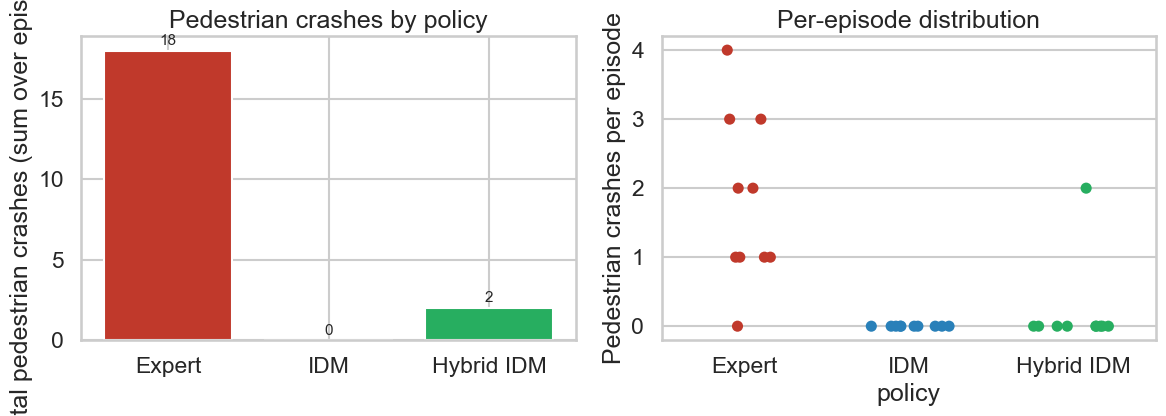

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

order = ["Expert", "IDM", "Hybrid IDM"]
colors = {"Expert": "#c0392b", "IDM": "#2980b9", "Hybrid IDM": "#27ae60"}

summary_ped = (
    pd.concat(
        [
            expert[["policy", "crash_ped"]],
            idm[["policy", "crash_ped"]],
            hybrid[["policy", "crash_ped"]],
        ],
        ignore_index=True,
    )
    .groupby("policy")["crash_ped"]
    .agg(total="sum", mean_per_ep="mean")
    .reset_index()
)
summary_ped["policy"] = pd.Categorical(summary_ped["policy"], categories=order, ordered=True)
summary_ped = summary_ped.sort_values("policy")

ax = axes[0]
bars = ax.bar(summary_ped["policy"], summary_ped["total"], color=[colors[p] for p in summary_ped["policy"]])
ax.set_ylabel("Total pedestrian crashes (sum over episodes)")
ax.set_title("Pedestrian crashes by policy")
for rect, v in zip(bars, summary_ped["total"]):
    ax.text(rect.get_x() + rect.get_width() / 2, rect.get_height() + 0.15, str(int(v)), ha="center", va="bottom", fontsize=11)

ax = axes[1]
plot_df = pd.concat(
    [
        expert.assign(policy="Expert")[["policy", "Episode", "crash_ped"]],
        idm.assign(policy="IDM")[["policy", "Episode", "crash_ped"]],
        hybrid.assign(policy="Hybrid IDM")[["policy", "Episode", "crash_ped"]],
    ],
    ignore_index=True,
)
plot_df["policy"] = pd.Categorical(plot_df["policy"], categories=order, ordered=True)
sns.stripplot(data=plot_df, x="policy", y="crash_ped", hue="policy", order=order, palette=colors, ax=ax, legend=False, jitter=0.25, size=8)
ax.set_ylabel("Pedestrian crashes per episode")
ax.set_title("Per-episode distribution")

plt.tight_layout()
plt.show()

## 2. Timeouts (IDM often does not finish the route)

Timeouts here reflect episodes that ended under a **stuck or non-progress** condition in your IDM runs (no goal time and no average speed recorded in the workbook for those rows). Hybrid IDM in the same LAP 1 window completes more often, which supports a **better street efficiency** story when paired with low pedestrian crash counts.

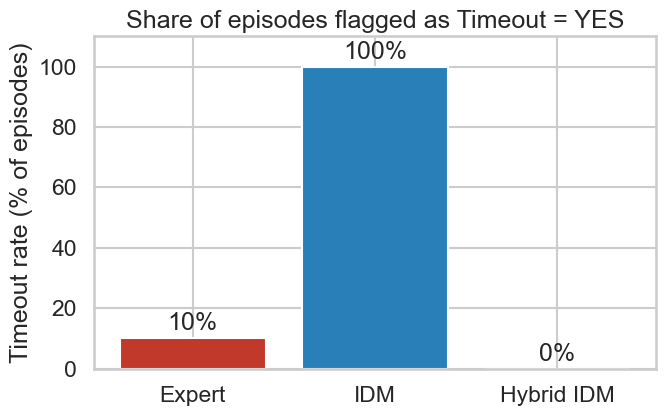

,policy,timeout_rate
0,Expert,10.0
1,IDM,100.0
2,Hybrid IDM,0.0


In [10]:
fig, ax = plt.subplots(figsize=(7, 4.5))

timeout_rates = []
for label, df in [("Expert", expert), ("IDM", idm), ("Hybrid IDM", hybrid)]:
    timeout_rates.append({"policy": label, "timeout_rate": df["timeout_flag"].mean() * 100})

tr = pd.DataFrame(timeout_rates)
tr["policy"] = pd.Categorical(tr["policy"], categories=order, ordered=True)
bars = ax.bar(tr["policy"], tr["timeout_rate"], color=[colors[p] for p in tr["policy"]])
ax.set_ylabel("Timeout rate (% of episodes)")
ax.set_title("Share of episodes flagged as Timeout = YES")
ax.set_ylim(0, max(15.0, float(tr["timeout_rate"].max()) * 1.1))
for rect, v in zip(bars, tr["timeout_rate"]):
    ax.text(rect.get_x() + rect.get_width() / 2, rect.get_height() + 1.0, f"{v:.0f}%", ha="center", va="bottom")
plt.tight_layout()
plt.show()

display(tr.assign(timeout_rate=lambda d: d["timeout_rate"].round(1)))

## 3. Pass rate and speed when the goal is reached

Average speed is computed only over episodes with a numeric goal time (route completed in simulation).

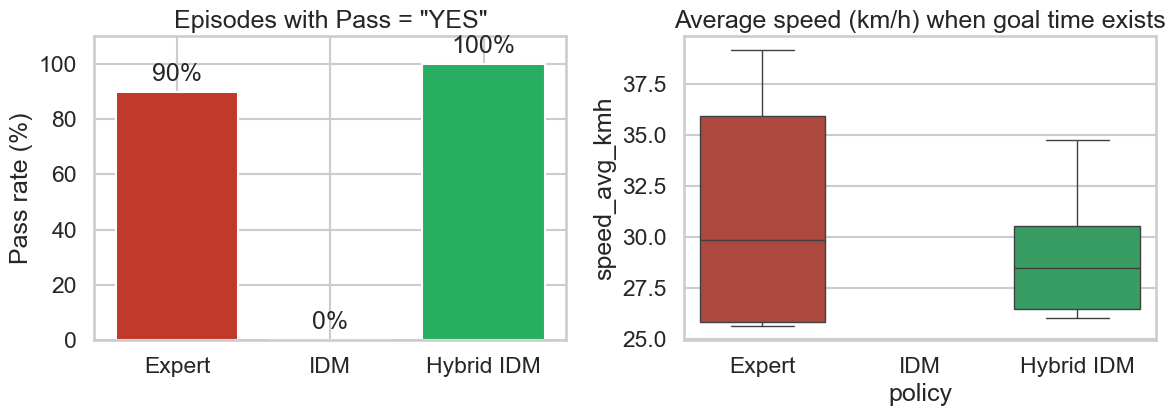

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

pass_rates = []
for label, df in [("Expert", expert), ("IDM", idm), ("Hybrid IDM", hybrid)]:
    pass_rates.append({"policy": label, "pass_rate": df["pass_flag"].mean() * 100})
pr = pd.DataFrame(pass_rates)
pr["policy"] = pd.Categorical(pr["policy"], categories=order, ordered=True)

ax = axes[0]
bars = ax.bar(pr["policy"], pr["pass_rate"], color=[colors[p] for p in pr["policy"]])
ax.set_ylabel("Pass rate (%)")
ax.set_title('Episodes with Pass = "YES"')
ax.set_ylim(0, 110)
for rect, v in zip(bars, pr["pass_rate"]):
    ax.text(rect.get_x() + rect.get_width() / 2, rect.get_height() + 2, f"{v:.0f}%", ha="center", va="bottom")

ax = axes[1]
spd_parts = []
for label, df in [("Expert", expert), ("IDM", idm), ("Hybrid IDM", hybrid)]:
    m = df["time_goal_sim_s"].notna() & df["speed_avg_kmh"].notna()
    spd_parts.append(df.loc[m, ["policy", "speed_avg_kmh"]])
spd = pd.concat(spd_parts, ignore_index=True)
spd["policy"] = pd.Categorical(spd["policy"], categories=order, ordered=True)
sns.boxplot(
    data=spd,
    x="policy",
    y="speed_avg_kmh",
    order=order,
    hue="policy",
    hue_order=order,
    palette=colors,
    dodge=False,
    legend=False,
    ax=ax,
)
ax.set_title("Average speed (km/h) when goal time exists")
ax.set_ylabel("speed_avg_kmh")

plt.tight_layout()
plt.show()

## 4. Compact comparison table (LAP 1 Hybrid vs ten-episode Expert and IDM)

Use this table in the report as a numeric summary next to the figures.

In [12]:
rows = []
for label, df in [("Expert", expert), ("IDM", idm), ("Hybrid IDM (LAP 1)", hybrid)]:
    m = df["time_goal_sim_s"].notna()
    rows.append(
        {
            "policy": label,
            "episodes": len(df),
            "mean_ped_crashes_per_ep": round(df["crash_ped"].mean(), 3),
            "total_ped_crashes": int(df["crash_ped"].sum()),
            "timeout_rate_%": round(df["timeout_flag"].mean() * 100, 1),
            "pass_rate_%": round(df["pass_flag"].mean() * 100, 1),
            "mean_speed_kmh_when_goal": round(df.loc[m, "speed_avg_kmh"].mean(), 2) if m.any() else np.nan,
            "mean_goal_time_sim_s": round(df.loc[m, "time_goal_sim_s"].mean(), 2) if m.any() else np.nan,
        }
    )

summary_tbl = pd.DataFrame(rows)
display(summary_tbl)

,policy,episodes,mean_ped_crashes_per_ep,total_ped_crashes,timeout_rate_%,pass_rate_%,mean_speed_kmh_when_goal,mean_goal_time_sim_s
0,Expert,10,1.8,18,10.0,90.0,31.24,140.26
1,IDM,10,0.0,0,100.0,0.0,NaN,NaN
2,Hybrid IDM (LAP 1),10,0.2,2,0.0,100.0,28.99,148.71


## 5. Interpretation

- **Expert** — The strip plot and totals show whether pedestrian contacts happen in **most laps**. Even occasional pedestrian crashes are unacceptable for a safety argument. Your spreadsheet supports highlighting Expert as **high risk** on this metric.
- **IDM** — A high **timeout** share matches the narrative that pure IDM-style caution can **freeze progress** near pedestrians even when a human-like gap might exist. That is an **efficiency and mission-completion** failure on the street route.
- **Hybrid IDM** — During ten episodesof run, compare **pedestrian crash totals relative to Expert**, **timeout rate relative to IDM**, and **pass rate plus speed** when the goal is reached. If the workbook shows far fewer pedestrian contacts than Expert and far fewer timeouts than IDM, the figures support **Hybrid IDM as a better street-scenario compromise** between lethal contact risk and standstill behavior.

Hence , the optimized policy which is the Hybrid IDM policy is better suitable for street scenerio.